In [19]:
import pandas as pd
import numpy as np
import re
import os
from google.colab import drive

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
    matthews_corrcoef, roc_curve, auc,
    precision_recall_curve, average_precision_score)

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/NLP_datasets/Phishing_Email_Dataset/'

original_files = ['CEAS_08.csv', 'Ling.csv', 'Enron.csv', 'Nazario.csv', 'SpamAssasin.csv', 'Nigerian_Fraud.csv']

dataframes = []
for file in original_files:
    df = pd.read_csv(path + file)
    df['source_file'] = file.replace('.csv', '')
    dataframes.append(df)
    print(f"Загружен {file}: {df.shape}")

Загружен CEAS_08.csv: (39154, 8)
Загружен Ling.csv: (2859, 4)
Загружен Enron.csv: (29767, 4)
Загружен Nazario.csv: (1565, 8)
Загружен SpamAssasin.csv: (5809, 8)
Загружен Nigerian_Fraud.csv: (3332, 8)


In [4]:
desired_columns = ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

dataframes_unified = []
for df in dataframes:
    df_copy = df.copy()
    for col in desired_columns:
        if col not in df_copy.columns:
            df_copy[col] = np.nan
    df_copy = df_copy[desired_columns + ['source_file']]
    dataframes_unified.append(df_copy)
    print(f"Файл {df_copy['source_file'].iloc[0]} приведён к форме: {df_copy.shape}")

Файл CEAS_08 приведён к форме: (39154, 8)
Файл Ling приведён к форме: (2859, 8)
Файл Enron приведён к форме: (29767, 8)
Файл Nazario приведён к форме: (1565, 8)
Файл SpamAssasin приведён к форме: (5809, 8)
Файл Nigerian_Fraud приведён к форме: (3332, 8)


In [5]:
df_clean = pd.concat(dataframes_unified, ignore_index=True)
print(f"Размер объединённого чистого датасета: {df_clean.shape}")
print(f"Количество дубликатов: {df_clean.duplicated().sum()}")

df_clean = df_clean.drop_duplicates()
print(f"Размер после удаления дубликатов: {df_clean.shape}")

print("\nРаспределение целевой переменной 'label':")
print(df_clean['label'].value_counts())

print("\nПропуски в процентах:")
print((df_clean.isnull().sum() / len(df_clean)) * 100)

Размер объединённого чистого датасета: (82486, 8)
Количество дубликатов: 0
Размер после удаления дубликатов: (82486, 8)

Распределение целевой переменной 'label':
label
1    42891
0    39595
Name: count, dtype: int64

Пропуски в процентах:
sender         39.954659
receiver       42.089567
date           40.138933
subject         0.420677
body            0.001212
label           0.000000
urls           39.553379
source_file     0.000000
dtype: float64


In [6]:
df_clean.to_csv(path + 'phishing_email_clean.csv', index=False)
print("Датасет сохранён как phishing_email_clean.csv")

Датасет сохранён как phishing_email_clean.csv


Статистика длины текста (в словах):
count     82486.000000
mean        279.232682
std         806.504063
min           1.000000
25%          58.000000
50%         136.000000
75%         306.000000
max      127127.000000
Name: text_len, dtype: float64


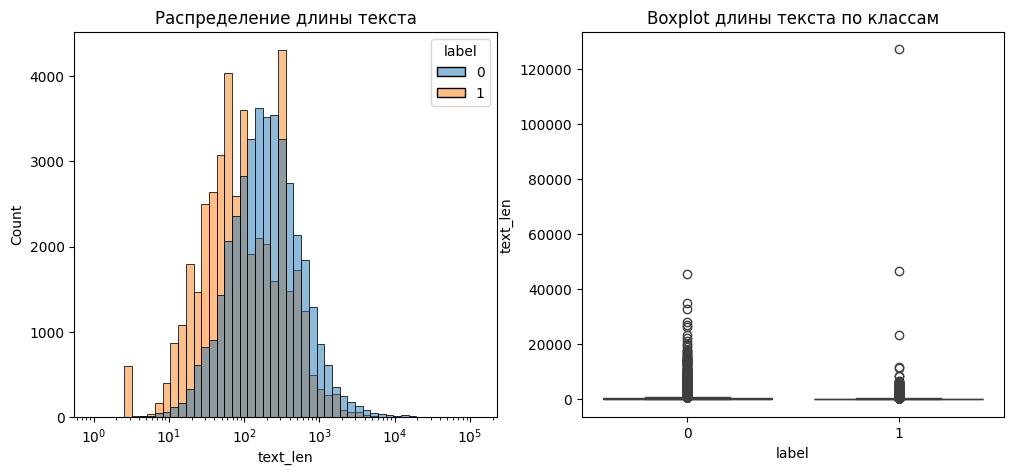


Средние значения новых признаков по классам:


,caps_ratio,url_count,exclamation_count,is_html
label,,,,
0,0.027446,0.377548,1.054275,0.050663
1,0.051805,0.439649,1.550838,0.075494


In [7]:
df_clean['full_text'] = df_clean['subject'].fillna('') + ' ' + df_clean['body'].fillna('')

df_clean['text_len'] = df_clean['full_text'].apply(lambda x: len(str(x).split()))
df_clean['subject_len'] = df_clean['subject'].fillna('').apply(lambda x: len(str(x).split()))
df_clean['body_len'] = df_clean['body'].fillna('').apply(lambda x: len(str(x).split()))
df_clean['has_url'] = (df_clean['urls'] > 0).astype(int)
df_clean['url_count'] = df_clean['urls'].fillna(0)
df_clean['exclamation_count'] = df_clean['full_text'].apply(lambda x: str(x).count('!'))
df_clean['question_count'] = df_clean['full_text'].apply(lambda x: str(x).count('?'))
df_clean['caps_ratio'] = df_clean['full_text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1))
df_clean['is_html'] = df_clean['full_text'].apply(lambda x: 1 if '<' in str(x) else 0)
df_clean['short_word_ratio'] = df_clean['full_text'].apply(lambda x: sum(1 for w in str(x).split() if len(w) < 3) / (len(str(x).split()) + 1))

print("Статистика длины текста (в словах):")
print(df_clean['text_len'].describe())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=df_clean, x='text_len', hue='label', bins=50, log_scale=True)
plt.title('Распределение длины текста')

plt.subplot(1,2,2)
sns.boxplot(data=df_clean, x='label', y='text_len')
plt.title('Boxplot длины текста по классам')
plt.show()

print("\nСредние значения новых признаков по классам:")
display(df_clean.groupby('label')[['caps_ratio', 'url_count', 'exclamation_count', 'is_html']].mean())

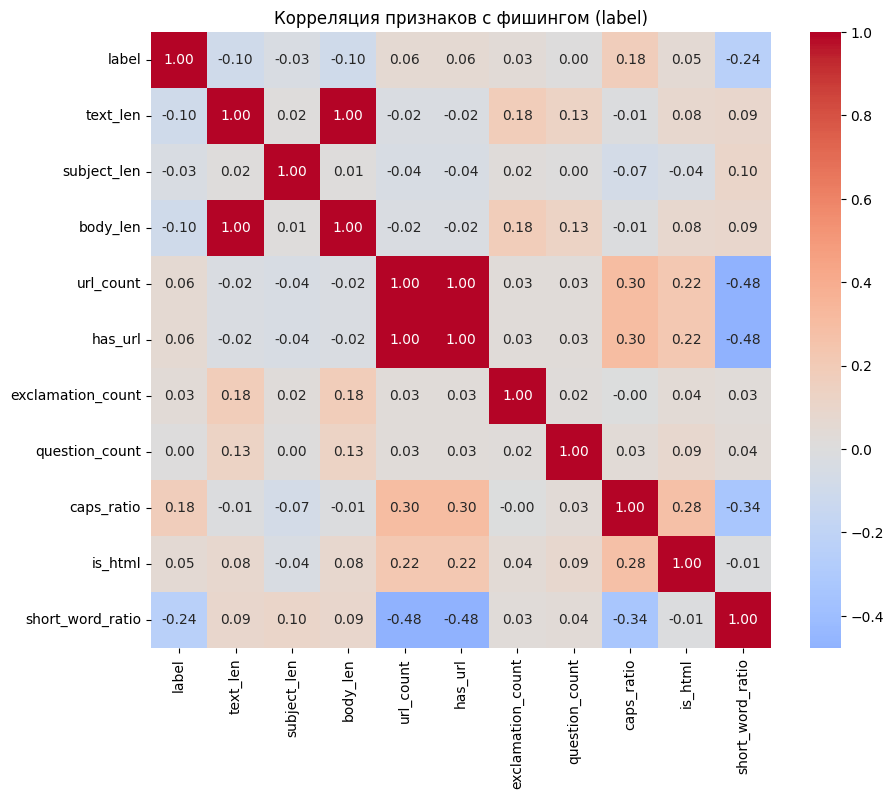


Сравнение средних значений (0 - Легитимное, 1 - Фишинг):


,caps_ratio,url_count,exclamation_count,short_word_ratio
label,,,,
0,0.027446,0.377548,1.054275,0.317352
1,0.051805,0.439649,1.550838,0.247400


In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[['label', 'text_len', 'subject_len', 'body_len', 'url_count',
                               'has_url', 'exclamation_count', 'question_count',
                               'caps_ratio', 'is_html', 'short_word_ratio']].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Корреляция признаков с фишингом (label)')
plt.show()

print("\nСравнение средних значений (0 - Легитимное, 1 - Фишинг):")
comparison = df_clean.groupby('label')[['caps_ratio', 'url_count', 'exclamation_count', 'short_word_ratio']].mean()
display(comparison)

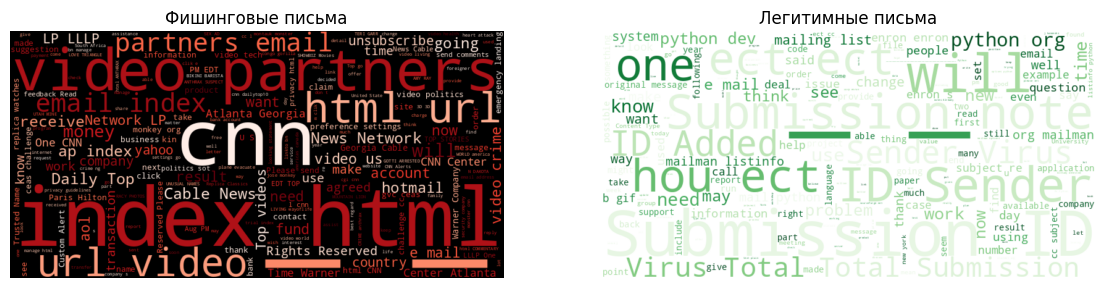

In [9]:
phishing_text = ' '.join(df_clean[df_clean['label']==1]['full_text'].astype(str).tolist())
legit_text = ' '.join(df_clean[df_clean['label']==0]['full_text'].astype(str).tolist())

wordcloud_phish = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(phishing_text)
wordcloud_legit = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(legit_text)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(wordcloud_phish, interpolation='bilinear')
plt.title('Фишинговые письма')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wordcloud_legit, interpolation='bilinear')
plt.title('Легитимные письма')
plt.axis('off')
plt.show()

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s\.]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

In [11]:
df_clean['clean_text'] = df_clean['full_text'].apply(clean_text)

df_clean.to_csv(path + 'phishing_email_clean_prepared.csv', index=False)
print("Предобработка завершена, датасет сохранён.")

Предобработка завершена, датасет сохранён.


In [12]:
num_features = ['text_len', 'subject_len', 'body_len', 'url_count', 'has_url',
                'exclamation_count', 'question_count', 'caps_ratio', 'is_html', 'short_word_ratio']

X = df_clean[['clean_text'] + num_features]
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

preprocessor = ColumnTransformer(transformers=[('text', TfidfVectorizer(max_features=5000, ngram_range=(1,2)), 'clean_text'),
        ('num', StandardScaler(), num_features)])

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

lr_pipeline.fit(X_train, y_train)

X_train_transformed = lr_pipeline.named_steps['preprocessor'].transform(X_train)
print(f"Размерность матрицы признаков (обучение): {X_train_transformed.shape}")

y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

tpr = tp / (tp + fn)
fnr = fn / (tp + fn)
roc_auc = roc_auc_score(y_test, y_proba)
fpr = fp / (fp + tn)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, y_pred)


print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:")
print(f"1. Успешное обнаружение (TPR):      {tpr:.4f}")
print(f"2. Пропущенные атаки (FNR):         {fnr:.4f}")
print(f"3. ROC-AUC:                         {roc_auc:.4f}")
print(f"4. Частота ложных тревог (FPR):     {fpr:.4f}")
print(f"5. Специфичность (Specificity):     {specificity:.4f}")
print(f"6. Коэффициент Мэтьюса (MCC):       {mcc:.4f}")

print(classification_report(y_test, y_pred, target_names=['Legit', 'Phishing']))

Размер обучающей выборки: (65988, 11)
Размер тестовой выборки: (16498, 11)
Размерность матрицы признаков (обучение): (65988, 5010)
ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
1. Успешное обнаружение (TPR):      0.9837
2. Пропущенные атаки (FNR):         0.0163
3. ROC-AUC:                         0.9976
4. Частота ложных тревог (FPR):     0.0256
5. Специфичность (Specificity):     0.9744
6. Коэффициент Мэтьюса (MCC):       0.9584
              precision    recall  f1-score   support

       Legit       0.98      0.97      0.98      7919
    Phishing       0.98      0.98      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



In [13]:
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=20, random_state=42))])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()

tpr_dt = tp / (tp + fn)
fnr_dt = fn / (tp + fn)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
fpr_dt = fp / (fp + tn)
specificity_dt = tn / (tn + fp)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)


print("ДЕРЕВО РЕШЕНИЙ")
print(f"1. Успешное обнаружение (TPR):      {tpr_dt:.4f}")
print(f"2. Пропущенные атаки (FNR):         {fnr_dt:.4f}")
print(f"3. ROC-AUC:                         {roc_auc_dt:.4f}")
print(f"4. Частота ложных тревог (FPR):     {fpr_dt:.4f}")
print(f"5. Специфичность (Specificity):     {specificity_dt:.4f}")
print(f"6. Коэффициент Мэтьюса (MCC):       {mcc_dt:.4f}")

print(classification_report(y_test, y_pred_dt, target_names=['Legit', 'Phishing']))

ДЕРЕВО РЕШЕНИЙ
1. Успешное обнаружение (TPR):      0.9281
2. Пропущенные атаки (FNR):         0.0719
3. ROC-AUC:                         0.9579
4. Частота ложных тревог (FPR):     0.0644
5. Специфичность (Specificity):     0.9356
6. Коэффициент Мэтьюса (MCC):       0.8633
              precision    recall  f1-score   support

       Legit       0.92      0.94      0.93      7919
    Phishing       0.94      0.93      0.93      8579

    accuracy                           0.93     16498
   macro avg       0.93      0.93      0.93     16498
weighted avg       0.93      0.93      0.93     16498



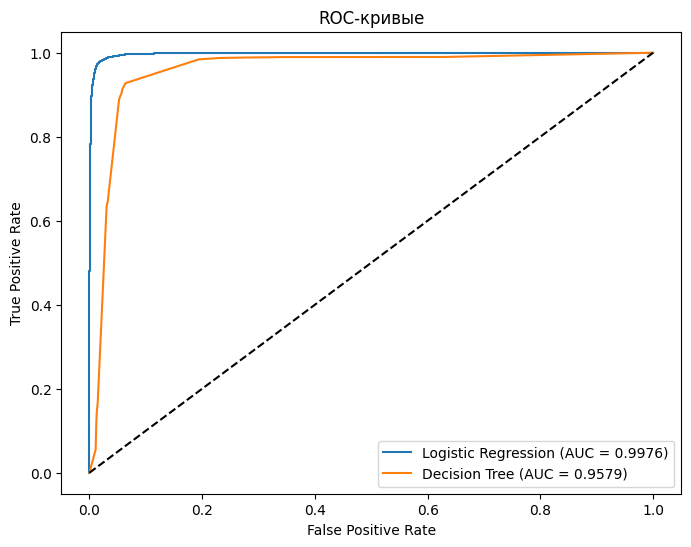

In [14]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.show()

In [15]:
tfidf_features = lr_pipeline.named_steps['preprocessor'].named_transformers_['text'].get_feature_names_out()

all_feature_names = list(tfidf_features) + num_features

coef = lr_pipeline.named_steps['classifier'].coef_.flatten()

print(f"Всего признаков в модели: {len(all_feature_names)}")

Всего признаков в модели: 5010


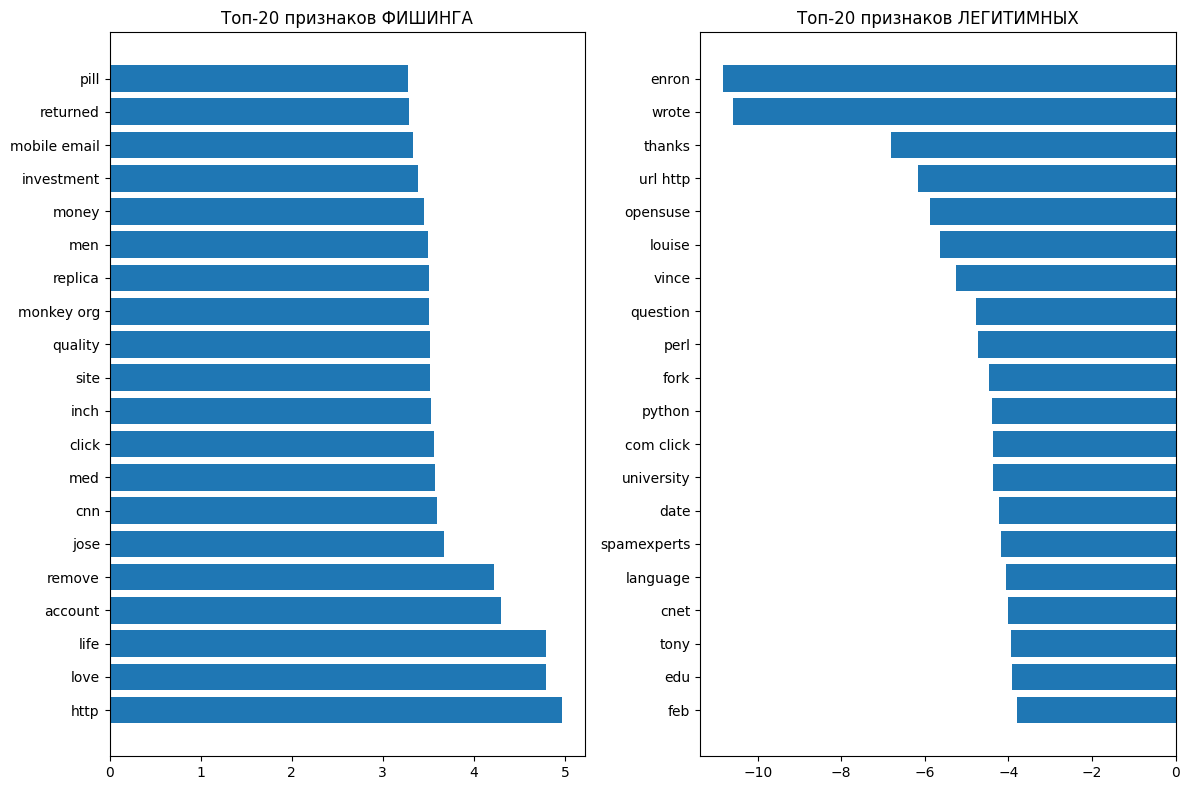

In [16]:
top_pos_idx = np.argsort(coef)[-20:]
top_neg_idx = np.argsort(coef)[:20]

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.barh(range(20), coef[top_pos_idx][::-1])
plt.yticks(range(20), [all_feature_names[i] for i in top_pos_idx][::-1])
plt.title('Топ-20 признаков ФИШИНГА')

plt.subplot(1, 2, 2)
plt.barh(range(20), coef[top_neg_idx][::-1])
plt.yticks(range(20), [all_feature_names[i] for i in top_neg_idx][::-1])
plt.title('Топ-20 признаков ЛЕГИТИМНЫХ')

plt.tight_layout()
plt.show()

In [17]:
fp_indices = np.where((y_test == 0) & (y_pred == 1))[0]
fn_indices = np.where((y_test == 1) & (y_pred == 0))[0]

print(f"Количество ложноположительных: {len(fp_indices)}")
print(f"Количество ложноотрицательных: {len(fn_indices)}")

print("\nПример ложноположительного письма:")
print(df_clean.iloc[fp_indices[0]]['full_text'][:500])

print("\nПример ложноотрицательного письма:")
print(df_clean.iloc[fn_indices[0]]['full_text'][:500])

Количество ложноположительных: 203
Количество ложноотрицательных: 140

Пример ложноположительного письма:
Re: [opensuse] Why can't I use "shutdown now" to turn off my system? Carlos E. R. wrote: > -----BEGIN PGP SIGNED MESSAGE----- > Hash: SHA1 >  >  >  > The Monday 2008-02-04 at 20:19 +0100, peter wrote: >  >>>  poweroff >>>  is the command I use. It's shorter :) >> >> 'init 6' is even shorter than 'poweroff'. >> But I think that 'halt' is the shortest at all. ;) >  > [ctrl][alt][supr] is even shorter :-P >  > You can define that combination to be reboot or halt. No need to be  > logged in. Which m

Пример ложноотрицательного письма:
[ie-rant] hp pavilion issues Hi all you techies out there in ierant land.
I recently formatted my hp pavillion(s7720.uk) in order to reinstall xp on
it. (Vista was driving me round the bend).
I'm not sure my machine was intended to run anything other than vista. Now
that I've installed xp on it I am missing certain drivers. \\most importantly
\\i cannot c

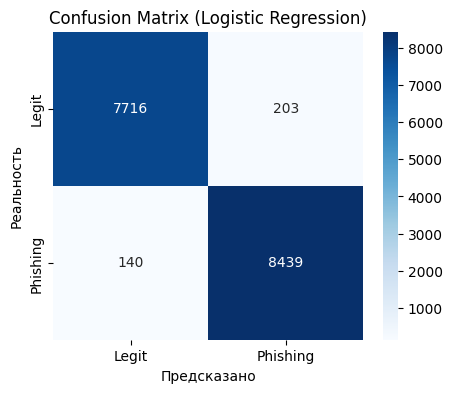

In [18]:
cm_lr = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Phishing'],
            yticklabels=['Legit', 'Phishing'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()